In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('laptop_price - dataset.csv')

In [3]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


# EDA

In [4]:
df.shape

(1275, 15)

In [5]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Memory',
       'GPU_Company', 'GPU_Type', 'OpSys', 'Weight (kg)', 'Price (Euro)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), int64(1), object(10)
me

In [7]:
df.describe()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


In [8]:
df.isna().sum()

Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: >

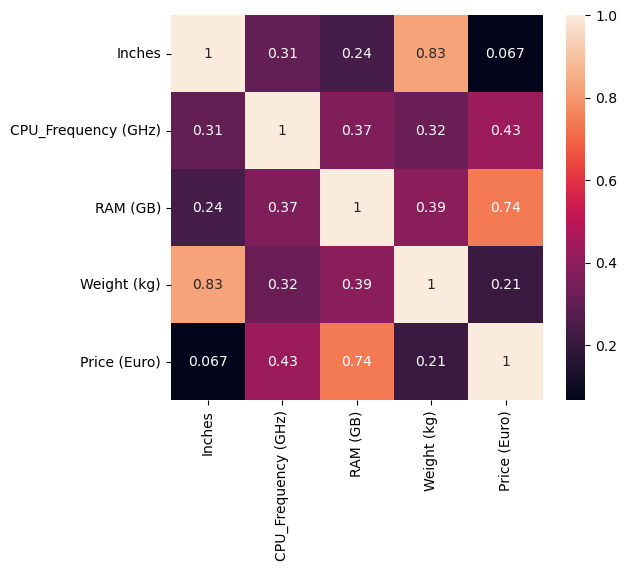

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [11]:
numeric_coulmns = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'Price (Euro)']
categorical_columns = ['Company', 'Product', 'TypeName', 'ScreenResolution',
       'CPU_Company', 'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys',]

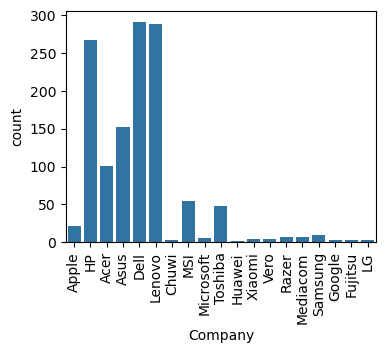

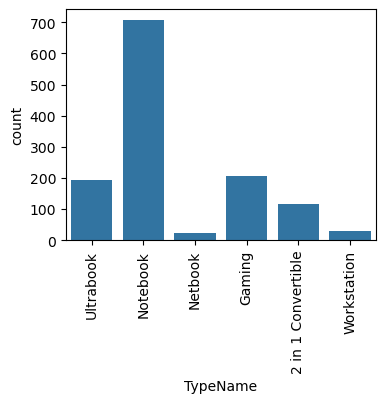

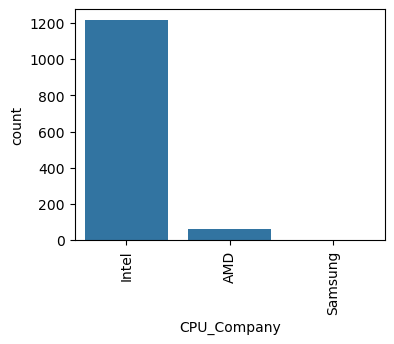

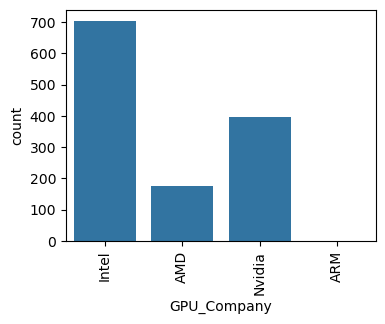

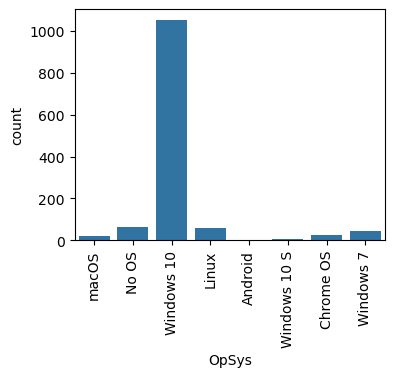

In [12]:
cate_columns = ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'OpSys',]

df['OpSys'] = df['OpSys'].replace('Mac OS X', 'macOS')

for cols in cate_columns:
    plt.figure(figsize=(4,3))
    plt.xticks(rotation=90)
    sns.countplot(data=df, x=cols,)

In [13]:
print(df[df['Company'] == 'Samsung'].shape[0])
print(df[df['CPU_Company'] == 'Samsung'].shape[0])

9
1


In [14]:
df[df['CPU_Company'] == 'Samsung']

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
1191,Samsung,Chromebook Plus,2 in 1 Convertible,12.3,IPS Panel Touchscreen 2400x1600,Samsung,Cortex A72&A53,2.0,4,32GB Flash Storage,ARM,Mali T860 MP4,Chrome OS,1.15,659.0


<Axes: xlabel='Price (Euro)', ylabel='Count'>

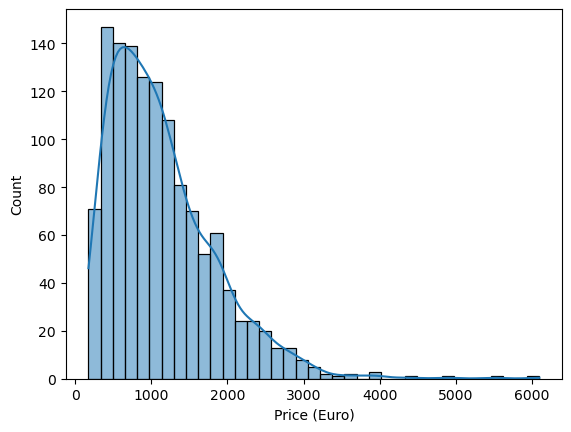

In [15]:
sns.histplot(df['Price (Euro)'], kde=True) 

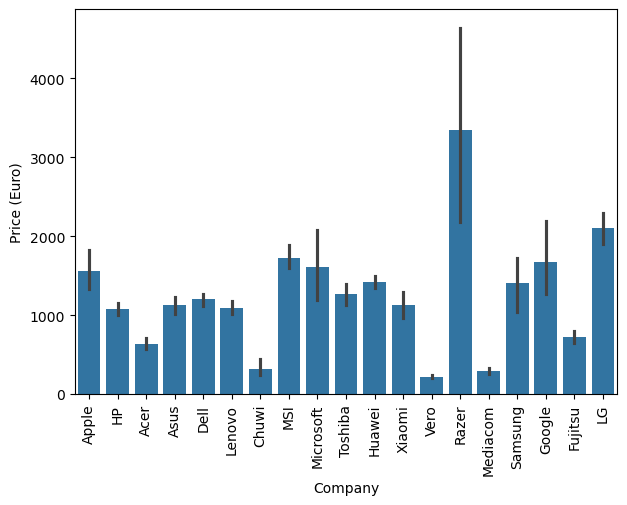

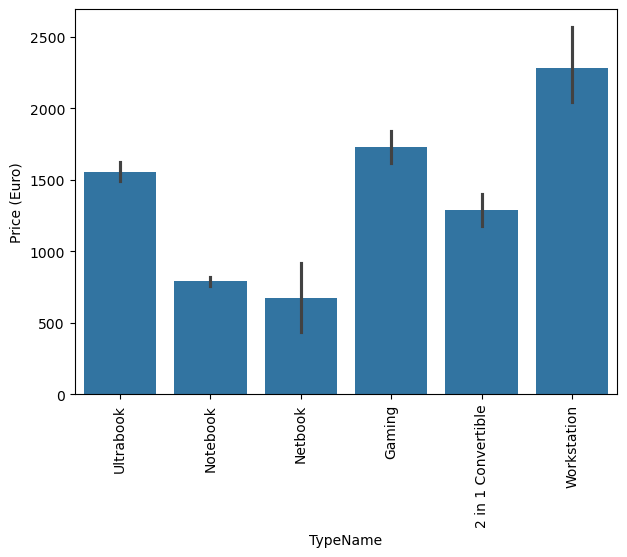

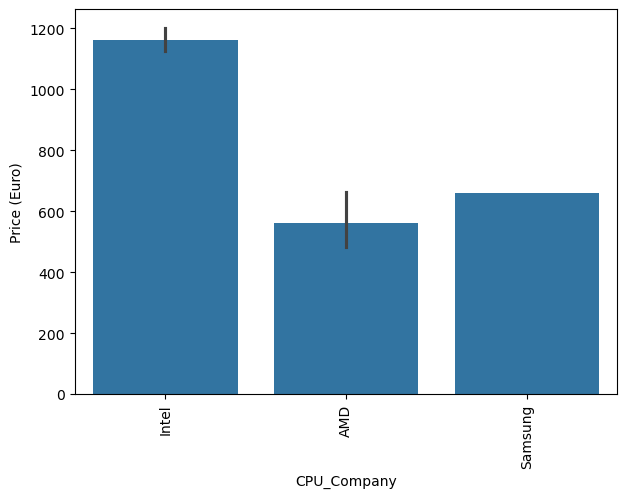

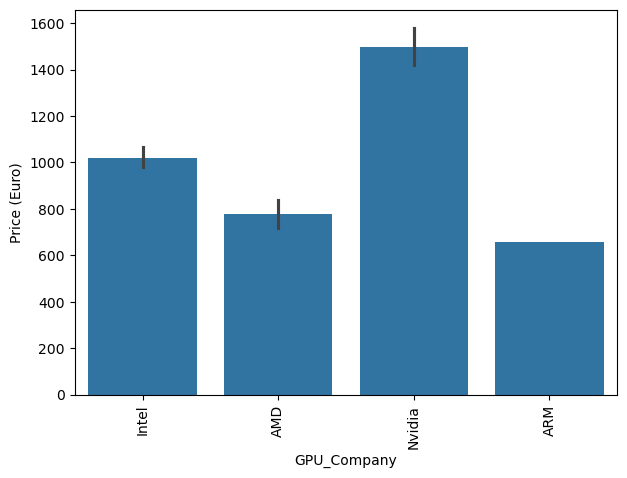

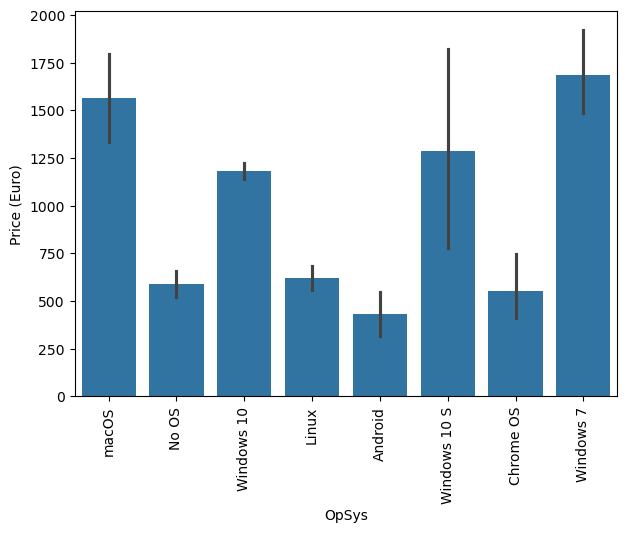

In [16]:

for cols in cate_columns: 
    plt.figure(figsize=(7, 5))
    sns.barplot(x=cols, y='Price (Euro)', data=df)
    plt.xticks(rotation=90)
    plt.show()

In [17]:
df[df['OpSys'] == 'Windows 10 S'][['Company', 'Product', 'Price (Euro)']]

,Company,Product,Price (Euro)
70,Microsoft,Surface Laptop,1089.00
104,Microsoft,Surface Laptop,1340.00
127,Asus,E402WA-GA007T (E2-6110/4GB/64GB/W10,277.99
449,Microsoft,Surface Laptop,2589.00
457,Microsoft,Surface Laptop,989.00
458,Microsoft,Surface Laptop,1799.00
500,Asus,VivoBook E201NA,340.00
670,Microsoft,Surface Laptop,1867.85


# EDA Insights

## Executive Summary & Data Quality

* Dataset Overview: The dataset consists of 1,275 rows and 15 columns with no missing (null) values or duplicated rows, ensuring high data integrity.

* Target Variable Distribution: The target variable Price (Euro) is right-skewed, indicating the presence of premium laptops acting as outliers ranging between 4,000 to 6,000 Euros.

## Key Insights from Numerical Features

* Core Correlations: All major numerical features show a strong correlation with laptop prices, with RAM (GB) and CPU Frequency being primary price drivers. Conversely, the screen size (Inches) shows a relatively weak correlation with the final price.

## Market Share & Demand Analysis (Univariate Trends)

* Dominant Brands & Types: HP, Dell, and Lenovo lead the market as the top-selling laptop brands. Among laptop types, Notebooks are heavily dominant, followed by Gaming laptops and Ultrabooks.
* Operating Systems: Windows 10 is overwhelmingly the most popular and frequently sold operating system.
* The Samsung Exception: Samsung has a minor footprint in this dataset with only 9 total products sold. Notably, it sold exactly one device powered by its own processor. Due to this negligible sample size, its bar in the CPU count plot appears virtually non-existent.

## Price Drivers & Market Dynamics (Bivariate Analysis)

* Premium Brands & Types: Razer emerges as the most expensive laptop brand, though its pricing exhibits high fluctuation. In terms of category, Workstations command the highest average price with a highly volatile price range, followed closely by Gaming laptops, which maintain a relatively stable pricing structure.

* Hardware Ecosystem: Intel dominates CPU sales, while AMD sits comfortably in a lower tier (between 0–200 units). In the GPU segment, Intel leads in volume, closely followed by Nvidia. However, Nvidia is distinctly more popular in specialized configurations, though its higher cost frequently steers budget-conscious buyers toward integrated Intel graphics

* Anomalies in Operating Systems: While macOS predictably sits at a premium price point, Windows 7 shows an unexpected resurgence, commanding a high average price. Additionally, Windows 10 S, despite its low adoption rate, displays a high average price accompanied by extreme price variation (variance) due to a mix of premium and budget devices in the data.

# Feature Engineering

In [18]:
df_copy = df.copy()

In [19]:
df_copy.tail()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
1270,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel,Core i7 6500U,2.5,4,128GB SSD,Intel,HD Graphics 520,Windows 10,1.80,638.0
1271,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel,Core i7 6500U,2.5,16,512GB SSD,Intel,HD Graphics 520,Windows 10,1.30,1499.0
1272,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel,Celeron Dual Core N3050,1.6,2,64GB Flash Storage,Intel,HD Graphics,Windows 10,1.50,229.0
1273,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel,Core i7 6500U,2.5,6,1TB HDD,AMD,Radeon R5 M330,Windows 10,2.19,764.0
1274,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel,Celeron Dual Core N3050,1.6,4,500GB HDD,Intel,HD Graphics,Windows 10,2.20,369.0


In [20]:
df_copy.drop(columns=['Product'], inplace=True)

In [21]:
df_copy['CPU_Type'].value_counts()

CPU_Type
Core i5 7200U       193
Core i7 7700HQ      147
Core i7 7500U       133
Core i3 6006U        81
Core i7 8550U        73
                   ... 
Core M m3             1
E-Series E2-9000      1
Core M M3-6Y30        1
A6-Series 7310        1
A9-Series 9410        1
Name: count, Length: 93, dtype: int64

In [22]:
def modify_cpu(text):
    if 'Core i7' in text:
        return 'Intel Core i7'
    elif 'Core i5' in text:
        return 'Intel Core i5'
    elif 'Core i3' in text:
        return 'Intel Core i3'
    elif 'Intel' in text:
        # Celeron, Pentium, Xeon and all others fall in this category
        return 'Other Intel Processor'
    elif 'AMD' in text or 'A-Series' in text or 'E-Series' in text or 'Ryzen' in text:
        # AMD models
        return 'AMD Processor'
    else:
        return 'Other'

In [23]:
df_copy['CPU_Brand'] = df_copy['CPU_Type'].apply(modify_cpu)

In [24]:
df_copy.head()

,Company,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),CPU_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,Intel Core i5
1,Apple,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,Intel Core i5
2,HP,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,Intel Core i5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,Intel Core i7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,Intel Core i5


In [25]:
split_res = df['ScreenResolution'].str.split('x')

# X_resolution
df_copy['X_resolution'] = split_res.str[0].str.extract(r'(\d+)$').astype(int)
# Y_resolution
df_copy['Y_resolution'] = split_res.str[1].astype(int)

In [26]:
df_copy.drop(columns=['CPU_Type'], inplace=True) 

In [27]:
df_copy['CPU_Brand'].value_counts()

CPU_Brand
Intel Core i7    515
Intel Core i5    423
Other            190
Intel Core i3    134
AMD Processor     13
Name: count, dtype: int64

In [28]:
df_copy.drop('ScreenResolution',axis=1, inplace=True)

In [29]:
df_copy.head()

,Company,TypeName,Inches,CPU_Company,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),CPU_Brand,X_resolution,Y_resolution
0,Apple,Ultrabook,13.3,Intel,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,Intel Core i5,2560,1600
1,Apple,Ultrabook,13.3,Intel,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,Intel Core i5,1440,900
2,HP,Notebook,15.6,Intel,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,Intel Core i5,1920,1080
3,Apple,Ultrabook,15.4,Intel,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,Intel Core i7,2880,1800
4,Apple,Ultrabook,13.3,Intel,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,Intel Core i5,2560,1600


In [30]:
df_copy['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          215
500GB HDD                        124
512GB SSD                        114
128GB SSD +  1TB HDD              94
128GB SSD                         74
256GB SSD +  1TB HDD              73
32GB Flash Storage                36
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           14
64GB Flash Storage                13
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
16GB Flash Storage                 7
1.0TB Hybrid                       7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [31]:
import re

def extract_all_memory(text):
    ssd, hdd, flash, hybrid = 0, 0, 0, 0
    
    text = str(text).replace('1.0TB', '1000GB').replace('1TB', '1000GB').replace('2TB', '2000GB')
    
    text = text.replace('Hybrid', 'HYBRID')
    
    parts = text.split('+')
    
    for part in parts:
        digits = re.findall(r'\d+', part)
        if digits:
            size = int(digits[0])
            
            if 'SSD' in part:
                ssd += size
            elif 'HDD' in part:
                hdd += size
            elif 'Flash' in part:
                flash += size
            elif 'HYBRID' in part:
                hybrid += size
                
    return pd.Series([ssd, hdd, flash, hybrid])

df_copy[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']] = df_copy['Memory'].apply(extract_all_memory)

df_copy.drop(columns=['Memory'], inplace=True)

df_copy[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].head()

,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB
0,128,0,0,0
1,0,0,128,0
2,256,0,0,0
3,512,0,0,0
4,256,0,0,0


In [32]:
df_copy.head()

,Company,TypeName,Inches,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),CPU_Brand,X_resolution,Y_resolution,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB
0,Apple,Ultrabook,13.3,Intel,2.3,8,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,Intel Core i5,2560,1600,128,0,0,0
1,Apple,Ultrabook,13.3,Intel,1.8,8,Intel,HD Graphics 6000,macOS,1.34,898.94,Intel Core i5,1440,900,0,0,128,0
2,HP,Notebook,15.6,Intel,2.5,8,Intel,HD Graphics 620,No OS,1.86,575.00,Intel Core i5,1920,1080,256,0,0,0
3,Apple,Ultrabook,15.4,Intel,2.7,16,AMD,Radeon Pro 455,macOS,1.83,2537.45,Intel Core i7,2880,1800,512,0,0,0
4,Apple,Ultrabook,13.3,Intel,3.1,8,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,Intel Core i5,2560,1600,256,0,0,0


In [33]:
df_copy['GPU_Type'].value_counts()

GPU_Type
HD Graphics 620     280
HD Graphics 520     181
UHD Graphics 620     68
GeForce GTX 1050     66
GeForce GTX 1060     48
                   ... 
Graphics 620          1
Radeon R5 520         1
Radeon R7             1
HD Graphics 540       1
Mali T860 MP4         1
Name: count, Length: 106, dtype: int64

In [34]:
def clean_gpu_type(text):
    text = str(text).lower()  
    
    if 'geforce' in text:
        return 'Nvidia GeForce'
    elif 'quadro' in text:
        return 'Nvidia Quadro'
    elif 'radeon' in text:
        return 'AMD Radeon'
    elif 'hd graphics' in text or 'uhd graphics' in text:
        return 'Intel HD/UHD Graphics'
    elif 'iris' in text:
        return 'Intel Iris Graphics'
    else:
        return 'Other GPU'

In [35]:
df_copy['GPU_Brand_Type'] = df_copy['GPU_Type'].apply(clean_gpu_type)

df_copy.drop(columns=['GPU_Type'], inplace=True)

df_copy.head() 

,Company,TypeName,Inches,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),CPU_Brand,X_resolution,Y_resolution,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,GPU_Brand_Type
0,Apple,Ultrabook,13.3,Intel,2.3,8,Intel,macOS,1.37,1339.69,Intel Core i5,2560,1600,128,0,0,0,Intel Iris Graphics
1,Apple,Ultrabook,13.3,Intel,1.8,8,Intel,macOS,1.34,898.94,Intel Core i5,1440,900,0,0,128,0,Intel HD/UHD Graphics
2,HP,Notebook,15.6,Intel,2.5,8,Intel,No OS,1.86,575.00,Intel Core i5,1920,1080,256,0,0,0,Intel HD/UHD Graphics
3,Apple,Ultrabook,15.4,Intel,2.7,16,AMD,macOS,1.83,2537.45,Intel Core i7,2880,1800,512,0,0,0,AMD Radeon
4,Apple,Ultrabook,13.3,Intel,3.1,8,Intel,macOS,1.37,1803.60,Intel Core i5,2560,1600,256,0,0,0,Intel Iris Graphics


In [36]:
# company, typename, cpu_company, GPU_company, OpSys, CPU_Brand, GPU_Brand_Type
columns_to_encode = ['Company', 'TypeName', 'CPU_Company', 'GPU_Company', 'OpSys', 'CPU_Brand', 'GPU_Brand_Type']

df_encoded = pd.get_dummies(df_copy, columns=columns_to_encode, drop_first=True, dtype=int)

df_encoded.head() 

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),X_resolution,Y_resolution,SSD_GB,HDD_GB,Flash_Storage_GB,...,OpSys_macOS,CPU_Brand_Intel Core i3,CPU_Brand_Intel Core i5,CPU_Brand_Intel Core i7,CPU_Brand_Other,GPU_Brand_Type_Intel HD/UHD Graphics,GPU_Brand_Type_Intel Iris Graphics,GPU_Brand_Type_Nvidia GeForce,GPU_Brand_Type_Nvidia Quadro,GPU_Brand_Type_Other GPU
0,13.3,2.3,8,1.37,1339.69,2560,1600,128,0,0,...,1,0,1,0,0,0,1,0,0,0
1,13.3,1.8,8,1.34,898.94,1440,900,0,0,128,...,1,0,1,0,0,1,0,0,0,0
2,15.6,2.5,8,1.86,575.00,1920,1080,256,0,0,...,0,0,1,0,0,1,0,0,0,0
3,15.4,2.7,16,1.83,2537.45,2880,1800,512,0,0,...,1,0,0,1,0,0,0,0,0,0
4,13.3,3.1,8,1.37,1803.60,2560,1600,256,0,0,...,1,0,1,0,0,0,1,0,0,0


# Model Training

In [37]:
X = df_encoded.drop('Price (Euro)', axis=1)
y = df_encoded['Price (Euro)']

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,AdaBoostRegressor 
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [39]:
scaler = StandardScaler()

In [40]:
scaler.fit_transform(X)

array([[-1.20574632, -0.00591761, -0.08649936, ..., -0.63210832,
        -0.15785948, -0.08891084],
       [-1.20574632, -0.99867429, -0.08649936, ..., -0.63210832,
        -0.15785948, -0.08891084],
       [ 0.40387315,  0.39118506, -0.08649936, ..., -0.63210832,
        -0.15785948, -0.08891084],
       ...,
       [-0.71586214, -1.39577696, -1.26393734, ..., -0.63210832,
        -0.15785948, -0.08891084],
       [ 0.40387315,  0.39118506, -0.47897869, ..., -0.63210832,
        -0.15785948, -0.08891084],
       [ 0.40387315, -1.39577696, -0.87145801, ..., -0.63210832,
        -0.15785948, -0.08891084]], shape=(1275, 54))

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [42]:
model_LR = LinearRegression()
model_KNN = KNeighborsRegressor()
model_Tree = DecisionTreeRegressor()
model_ridge = Ridge()
model_lasso = Lasso()
model_RF = RandomForestRegressor()
model_GB = GradientBoostingRegressor()
model_Ada = AdaBoostRegressor()

In [43]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(), 
    'Ridge': Ridge(),
    'Decision Tree': DecisionTreeRegressor(), 
    'KNN': KNeighborsRegressor(), 
    'Random Forest': RandomForestRegressor(), 
    'Gradient Boosting': GradientBoostingRegressor(), 
    'AdaBoost': AdaBoostRegressor(), 
}

In [44]:
results = []
n = X_test.shape[0]
k = X_test.shape[1]

for name,model in models.items(): 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores = r2_score(y_test, y_pred)
    MSE = mean_squared_error(y_test, y_pred)
    adj_r2 = 1 - ((1 - r2_scores) * (n - 1) / (n - k - 1)) 
    results.append({
        'name': name, 
        'r2_score': r2_scores, 
        'mean_squared_error': MSE, 
        'Adjusted_r2': adj_r2,
    })

In [45]:
results

[{'name': 'Linear Regression',
  'r2_score': 0.7867948533318263,
  'mean_squared_error': 105822.08787463533,
  'Adjusted_r2': 0.7292294637314194},
 {'name': 'Lasso',
  'r2_score': 0.7856562166381239,
  'mean_squared_error': 106387.2379854147,
  'Adjusted_r2': 0.7277833951304173},
 {'name': 'Ridge',
  'r2_score': 0.7883280851834479,
  'mean_squared_error': 105061.08468934627,
  'Adjusted_r2': 0.7311766681829788},
 {'name': 'Decision Tree',
  'r2_score': 0.7384083589838815,
  'mean_squared_error': 129838.20538798475,
  'Adjusted_r2': 0.6677786159095295},
 {'name': 'KNN',
  'r2_score': 0.7316043127431879,
  'mean_squared_error': 133215.32076459605,
  'Adjusted_r2': 0.6591374771838487},
 {'name': 'Random Forest',
  'r2_score': 0.8539402905109046,
  'mean_squared_error': 72495.1702810184,
  'Adjusted_r2': 0.8145041689488488},
 {'name': 'Gradient Boosting',
  'r2_score': 0.8703672107804329,
  'mean_squared_error': 64341.844587726686,
  'Adjusted_r2': 0.8353663576911498},
 {'name': 'AdaBoost'

In [46]:
model_GB.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [47]:
y_pred_gb = model_GB.predict(X_test)

In [48]:
r2_score(y_test, y_pred_gb)

0.8699741848088448

## Important Features

In [49]:
importances = model_GB.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


In [50]:
feature_imp_df.head(10)

,Feature,Importance
2,RAM (GB),0.397162
6,SSD_GB,0.129063
30,TypeName_Notebook,0.087038
3,Weight (kg),0.085979
47,CPU_Brand_Intel Core i7,0.057710
52,GPU_Brand_Type_Nvidia Quadro,0.041939
1,CPU_Frequency (GHz),0.040560
4,X_resolution,0.036548
0,Inches,0.020966
23,Company_Razer,0.016878


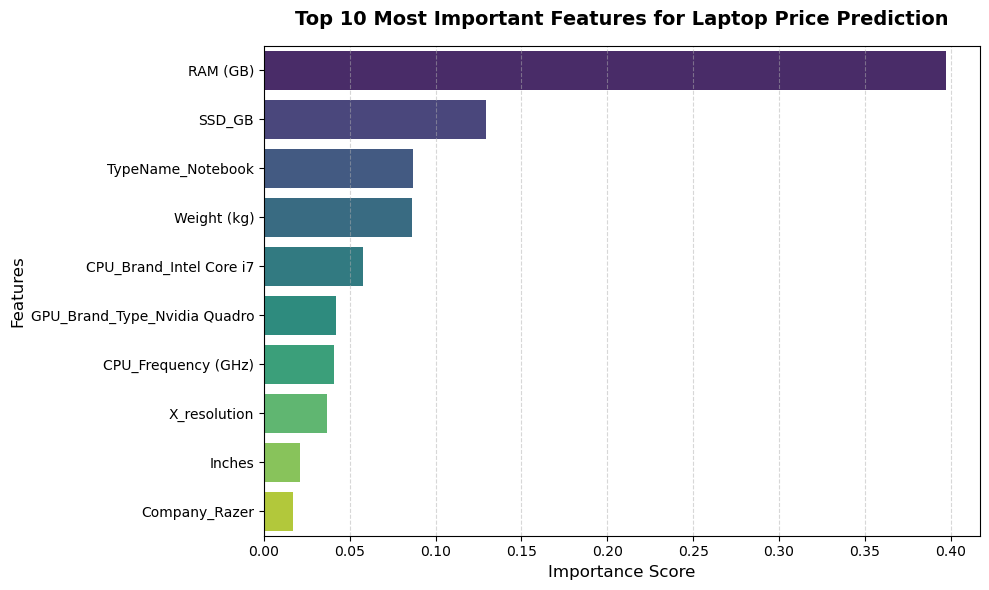

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis') 
plt.title('Top 10 Most Important Features for Laptop Price Prediction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12) 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout() # Yeh line labels ko katne se bachati hai
plt.show() 

## Modeling Phase & Feature Importance Insights

Following a rigorous Exploratory Data Analysis (EDA) and a systematic feature engineering pipeline, a **Gradient Boosting Regressor** was selected as the final model due to its superior predictive accuracy and robust handling of non-linear target distributions. 

The chart above illustrates the top 10 most influential features driving the model's pricing predictions. Below is a structured analysis of how the machine learning model interprets the laptop marketplace.

---

### 1. The Heavy Hitters: Core Hardware Drivers
* **RAM (GB) dominates the model at an importance score of 0.40.** This aligns perfectly with our EDA correlation metrics. Because our target variable `Price (Euro)` is heavily right-skewed with premium outliers up to 6,000 Euros, the Gradient Boosting algorithm heavily leverages RAM capacity to instantly segment budget notebooks from premium machines.
* **SSD Storage (GB) emerges as the second most critical metric (0.13).** Modern laptop pricing scales exponentially with solid-state storage capacity, making it a cleaner structural pricing proxy for the model than raw CPU clock speeds alone.

### 2. Capturing Segment and Form Factor Realities
* **TypeName_Notebook (0.09) & Weight (0.087):** Our EDA proved that generic "Notebooks" completely dominate market volume. By assigning a high negative/positive split weight to this specific type and pair-matching it with the device's physical weight, the Gradient Boosting trees successfully separate high-volume, lower-cost commodity laptops from sleek, dense premium ultrabooks or heavy gaming rigs.

### 3. Resolving Hardware Ecosystem Tiers
* **Intel Core i7 (0.057) & Nvidia Quadro (0.042):** While Intel leads overall market volume, the model selectively relies on premium tier indicators to justify price jumps. 
    * An **Intel Core i7** tag serves as a reliable threshold split for premium performance.
    * **Nvidia Quadro** represents specialized, hyper-expensive workstation GPUs. This perfectly explains our EDA finding where *Workstations commanded volatile, premium average prices*—the model relies on this precise GPU feature to map those extreme outlier price points (4,000+ Euros).

### 4. Niche Luxury Flags
* **Company_Razer (~0.017):** Even though the market share of Razer is low compared to giants like HP or Lenovo, the model isolates this specific brand flag. Because Razer consistently represents highly volatile, premium pricing tiers, the algorithm uses this node split to apply a luxury brand premium without throwing off baseline calculations for budget-conscious brands.

---

### 💡 Executive Modeling Summary

> **Conclusion:** > While high-volume market trends are heavily dictated by Windows 10 Notebooks from HP, Dell, and Lenovo, financial variance and high-end pricing are governed by specialized hardware configurations. 
>
> By utilizing a **Gradient Boosting Regressor**, the pricing engine successfully navigates the right-skewed distribution of laptop prices. Rather than getting confused by operating system variances (like the high volatility seen in Windows 10 S) or small sample sizes (such as Samsung's minor footprint), the sequential tree-building structure accurately maps complex hardware interactions to deliver highly generalized, industry-grade price predictions.